<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/research-v2/notebooks/13_v2_acceptance_predictors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q pandas scipy scikit-learn matplotlib seaborn

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
)

SEED = 42
NUMBER_OF_BOOTSTRAPS = 10000

In [3]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DRIVE_DIRECTORY = Path(
    "/content/drive/MyDrive/ma2288_nextlat"
)

POSITION_PATH = (
    DRIVE_DIRECTORY
    / "results_v2"
    / "tables"
    / "single_round_position_samples.csv"
)

ROUND_PATH = (
    DRIVE_DIRECTORY
    / "results_v2"
    / "tables"
    / "single_round_gamma_samples.csv"
)

position_df = pd.read_csv(
    POSITION_PATH
)

round_df = pd.read_csv(
    ROUND_PATH
)

print("Position rows:", len(position_df))
print("Round rows:", len(round_df))
print("Methods:", position_df["method"].unique())

Position rows: 7680
Round rows: 1920
Methods: ['One-step' 'Multi-step']


In [5]:
analysis_df = position_df[
    position_df["position"] > 1
].copy()

print("Analysis rows:", len(analysis_df))
print(
    "Overall acceptance:",
    analysis_df["would_accept"].mean(),
)

Analysis rows: 7200
Overall acceptance: 0.37041666666666667


In [6]:
overall_summary_df = (
    analysis_df
    .groupby(
        "method",
        as_index=False,
    )
    .agg(
        mean_output_kl=(
            "output_kl",
            "mean",
        ),
        mean_acceptance_probability=(
            "acceptance_probability",
            "mean",
        ),
        empirical_acceptance=(
            "would_accept",
            "mean",
        ),
        mean_normalized_l2=(
            "normalized_l2",
            "mean",
        ),
        mean_entropy=(
            "entropy",
            "mean",
        ),
    )
)

print(
    overall_summary_df.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.4f}"
        ),
    )
)

    method  mean_output_kl  mean_acceptance_probability  empirical_acceptance  mean_normalized_l2  mean_entropy
Multi-step          2.1037                       0.3741                0.3750              0.2144        5.9797
  One-step          2.2090                       0.3650                0.3658              0.2241        5.9659


In [7]:
analysis_df[
    "score_negative_kl"
] = -analysis_df["output_kl"]

analysis_df[
    "score_negative_l2"
] = -analysis_df["normalized_l2"]

analysis_df[
    "score_cosine"
] = analysis_df["cosine_similarity"]

analysis_df[
    "score_negative_entropy"
] = -analysis_df["entropy"]

analysis_df[
    "score_top1_margin"
] = analysis_df["top1_margin"]

In [8]:
score_settings = [
    (
        "Output KL",
        "score_negative_kl",
        False,
    ),
    (
        "Latent L2",
        "score_negative_l2",
        False,
    ),
    (
        "Cosine similarity",
        "score_cosine",
        False,
    ),
    (
        "Draft entropy",
        "score_negative_entropy",
        True,
    ),
    (
        "Top-1 margin",
        "score_top1_margin",
        True,
    ),
]

In [9]:
predictor_rows = []

for method_name in [
    "One-step",
    "Multi-step",
]:
    method_data = analysis_df[
        analysis_df["method"]
        == method_name
    ]

    labels = method_data[
        "would_accept"
    ].to_numpy()

    for (
        predictor_name,
        score_column,
        deployable,
    ) in score_settings:

        scores = method_data[
            score_column
        ].to_numpy()

        auroc = roc_auc_score(
            labels,
            scores,
        )

        average_precision = (
            average_precision_score(
                labels,
                scores,
            )
        )

        spearman_with_probability = (
            method_data[
                [
                    score_column,
                    "acceptance_probability",
                ]
            ]
            .corr(
                method="spearman"
            )
            .iloc[0, 1]
        )

        predictor_rows.append({
            "method": method_name,
            "predictor": predictor_name,
            "deployable": deployable,
            "auroc": auroc,
            "average_precision": (
                average_precision
            ),
            "spearman_with_acceptance_probability": (
                spearman_with_probability
            ),
        })

predictor_df = pd.DataFrame(
    predictor_rows
)

print(
    predictor_df.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.4f}"
        ),
    )
)

    method         predictor  deployable  auroc  average_precision  spearman_with_acceptance_probability
  One-step         Output KL       False 0.6851             0.5323                                0.4767
  One-step         Latent L2       False 0.5485             0.4106                                0.1519
  One-step Cosine similarity       False 0.5841             0.4380                                0.2400
  One-step     Draft entropy        True 0.5636             0.4370                                0.1347
  One-step      Top-1 margin        True 0.5699             0.4361                                0.1485
Multi-step         Output KL       False 0.6735             0.5377                                0.4758
Multi-step         Latent L2       False 0.5539             0.4213                                0.1588
Multi-step Cosine similarity       False 0.5719             0.4359                                0.2288
Multi-step     Draft entropy        True 0.5405        

In [10]:
position_relationship_df = (
    analysis_df
    .groupby(
        [
            "method",
            "position",
        ],
        as_index=False,
    )
    .agg(
        mean_output_kl=(
            "output_kl",
            "mean",
        ),
        mean_acceptance_probability=(
            "acceptance_probability",
            "mean",
        ),
        empirical_acceptance=(
            "would_accept",
            "mean",
        ),
    )
)

for method_name in [
    "One-step",
    "Multi-step",
]:
    method_positions = (
        position_relationship_df[
            position_relationship_df[
                "method"
            ]
            == method_name
        ]
    )

    correlation = (
        method_positions[
            [
                "mean_output_kl",
                "mean_acceptance_probability",
            ]
        ]
        .corr(
            method="spearman"
        )
        .iloc[0, 1]
    )

    print(
        method_name,
        "position-level KL/acceptance "
        "Spearman:",
        correlation,
    )

One-step position-level KL/acceptance Spearman: -0.7785714285714286
Multi-step position-level KL/acceptance Spearman: -0.4642857142857143


In [11]:
prompt_round_df = (
    round_df
    .groupby(
        [
            "method",
            "gamma",
            "prompt_index",
        ],
        as_index=False,
    )
    .agg(
        accepted_prefix_length=(
            "accepted_prefix_length",
            "mean",
        ),
        full_acceptance_rate=(
            "all_draft_tokens_accepted",
            "mean",
        ),
    )
)

In [12]:
def paired_prompt_bootstrap(
    prompt_round_df,
    gamma,
    metric,
    number_of_bootstraps=10000,
    seed=42,
):
    gamma_data = prompt_round_df[
        prompt_round_df["gamma"]
        == gamma
    ]

    pivot = gamma_data.pivot(
        index="prompt_index",
        columns="method",
        values=metric,
    ).dropna()

    # 正数表示 Multi-step 更好
    differences = (
        pivot["Multi-step"]
        - pivot["One-step"]
    ).to_numpy()

    rng = np.random.default_rng(
        seed
    )

    bootstrap_means = np.empty(
        number_of_bootstraps
    )

    number_of_prompts = len(
        differences
    )

    for bootstrap_index in range(
        number_of_bootstraps
    ):
        sampled_indices = rng.integers(
            0,
            number_of_prompts,
            size=number_of_prompts,
        )

        bootstrap_means[
            bootstrap_index
        ] = differences[
            sampled_indices
        ].mean()

    return {
        "point_estimate": (
            differences.mean()
        ),
        "ci_lower": np.percentile(
            bootstrap_means,
            2.5,
        ),
        "ci_upper": np.percentile(
            bootstrap_means,
            97.5,
        ),
        "probability_positive": (
            bootstrap_means > 0
        ).mean(),
    }

In [13]:
bootstrap_rows = []

for gamma in [2, 4, 8, 16]:
    result = paired_prompt_bootstrap(
        prompt_round_df=(
            prompt_round_df
        ),
        gamma=gamma,
        metric=(
            "accepted_prefix_length"
        ),
        number_of_bootstraps=(
            NUMBER_OF_BOOTSTRAPS
        ),
        seed=SEED + gamma,
    )

    bootstrap_rows.append({
        "gamma": gamma,
        "multistep_minus_onestep": (
            result["point_estimate"]
        ),
        "ci_lower": (
            result["ci_lower"]
        ),
        "ci_upper": (
            result["ci_upper"]
        ),
        "bootstrap_probability_positive": (
            result[
                "probability_positive"
            ]
        ),
    })

bootstrap_df = pd.DataFrame(
    bootstrap_rows
)

print(
    bootstrap_df.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.4f}"
        ),
    )
)

 gamma  multistep_minus_onestep  ci_lower  ci_upper  bootstrap_probability_positive
     2                   0.0083   -0.0208    0.0375                          0.7055
     4                  -0.0167   -0.0875    0.0542                          0.3244
     8                  -0.0417   -0.1458    0.0542                          0.2097
    16                  -0.0458   -0.1542    0.0542                          0.2010


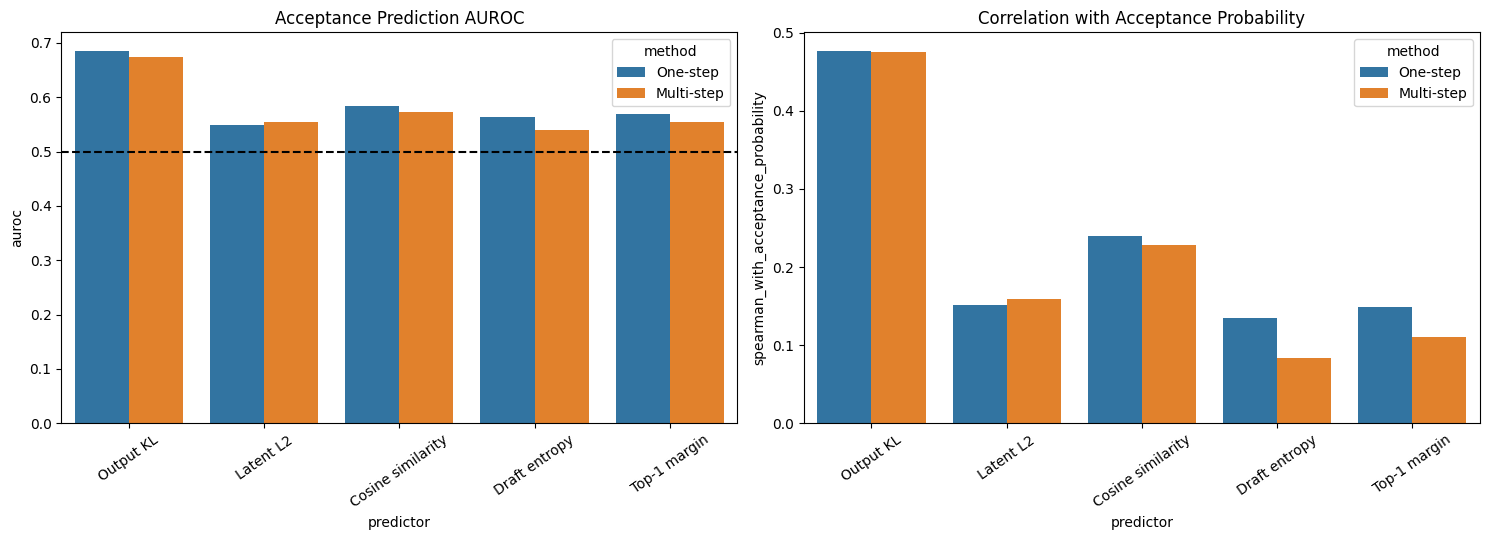

In [14]:
predictor_figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5.5),
)

sns.barplot(
    data=predictor_df,
    x="predictor",
    y="auroc",
    hue="method",
    ax=axes[0],
)

axes[0].axhline(
    0.5,
    color="black",
    linestyle="--",
)

axes[0].set_title(
    "Acceptance Prediction AUROC"
)

axes[0].tick_params(
    axis="x",
    rotation=35,
)

sns.barplot(
    data=predictor_df,
    x="predictor",
    y=(
        "spearman_with_"
        "acceptance_probability"
    ),
    hue="method",
    ax=axes[1],
)

axes[1].set_title(
    "Correlation with Acceptance Probability"
)

axes[1].tick_params(
    axis="x",
    rotation=35,
)

predictor_figure.tight_layout()
plt.show()

In [15]:
V2_RESULT_DIRECTORY = (
    DRIVE_DIRECTORY
    / "results_v2"
)

TABLE_DIRECTORY = (
    V2_RESULT_DIRECTORY
    / "tables"
)

FIGURE_DIRECTORY = (
    V2_RESULT_DIRECTORY
    / "figures"
)

predictor_df.to_csv(
    TABLE_DIRECTORY
    / "acceptance_predictor_comparison.csv",
    index=False,
)

bootstrap_df.to_csv(
    TABLE_DIRECTORY
    / "accepted_prefix_bootstrap.csv",
    index=False,
)

overall_summary_df.to_csv(
    TABLE_DIRECTORY
    / "on_policy_overall_summary.csv",
    index=False,
)

predictor_figure.savefig(
    FIGURE_DIRECTORY
    / "acceptance_predictor_comparison.png",
    dpi=250,
    bbox_inches="tight",
)